# PJM Hourly Energy Consumption Forecasting
### Linear Regression + Random Forest + ANN, compared on engineered time features

**Dataset:** [Hourly Energy Consumption](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption) (PJM Interconnection) — ~145,000 hourly electricity load readings (MW) for the PJME region, spanning January 2002 to August 2018.

**Approach:** treat forecasting as a supervised regression problem by engineering calendar, lag, and rolling-average features from the timestamp — the same core idea as a daily demand-forecasting project, but applied to a series with three overlapping seasonalities (hour-of-day, day-of-week, month) instead of one.

**Structure:**
1. Load & inspect data
2. EDA — overall trend, zoomed view, seasonality decomposition
3. Feature engineering — calendar, lag, and rolling features
4. Time-aware train/validation split
5. Models — Linear Regression, Random Forest, ANN
6. Evaluation & comparison
7. Key findings

**Requirements:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `tensorflow`


## 1. Load & inspect data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("PJME_hourly.csv", parse_dates=['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df['Datetime'].min(), "to", df['Datetime'].max())
print("Duplicate timestamps:", df['Datetime'].duplicated().sum())
print("Missing values:\n", df.isna().sum())

# Drop duplicate timestamps (likely daylight-saving "fall back" hours)
df = df.drop_duplicates(subset='Datetime').reset_index(drop=True)
print("Shape after dropping duplicate timestamps:", df.shape)

df['PJME_MW'].describe()


Shape: (145366, 2)
Date range: 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Duplicate timestamps: 4
Missing values:
 Datetime    0
PJME_MW     0
dtype: int64
Shape after dropping duplicate timestamps: (145362, 2)


count    145362.000000
mean      32080.510780
std        6463.866507
min       14544.000000
25%       27573.000000
50%       31421.000000
75%       35650.000000
max       62009.000000
Name: PJME_MW, dtype: float64

## 2. EDA

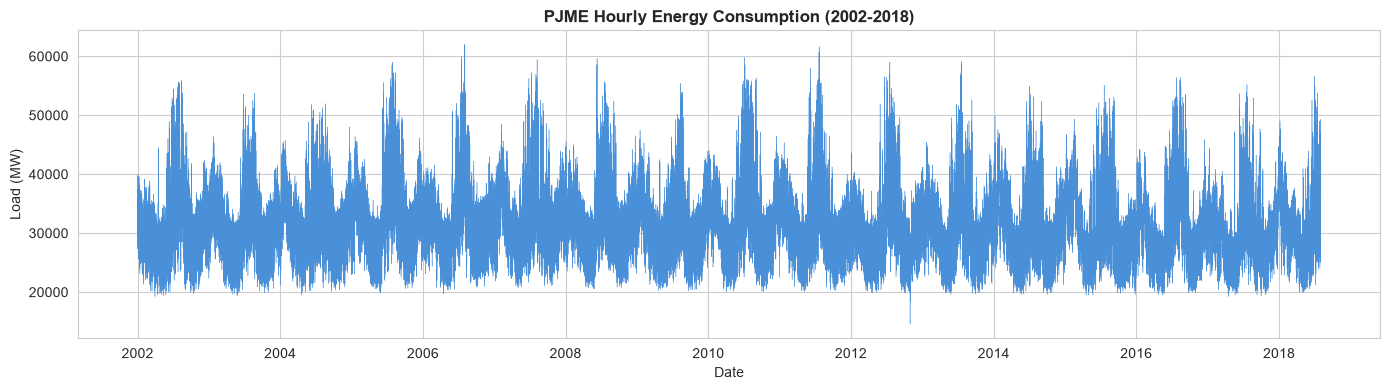

In [2]:
plt.figure(figsize=(14, 4))
plt.plot(df['Datetime'], df['PJME_MW'], color='#4A90D9', linewidth=0.3)
plt.title('PJME Hourly Energy Consumption (2002-2018)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.tight_layout()
plt.show()


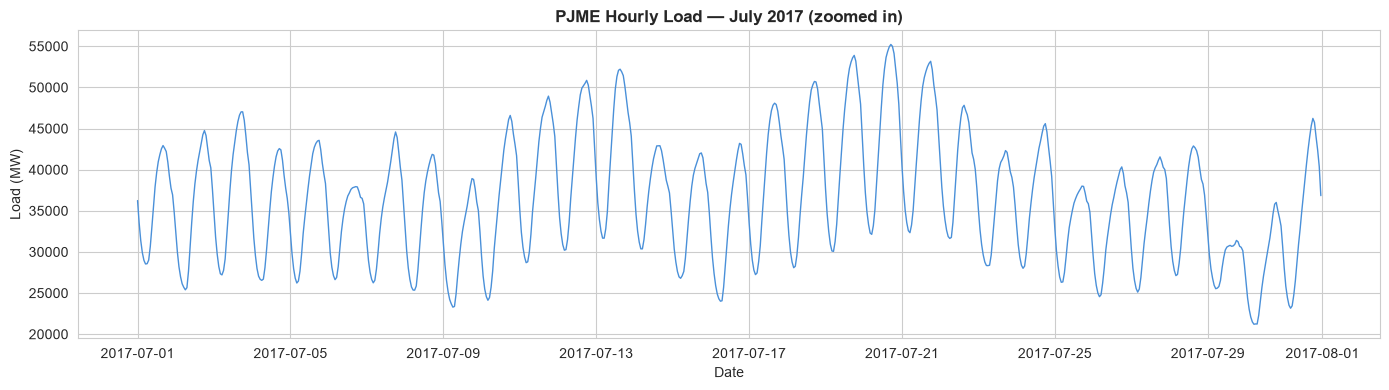

In [3]:
# 16 years of hourly data is too dense to read daily/hourly texture above — zoom into one month
sample = df[(df['Datetime'] >= '2017-07-01') & (df['Datetime'] < '2017-08-01')]

plt.figure(figsize=(14, 4))
plt.plot(sample['Datetime'], sample['PJME_MW'], color='#4A90D9', linewidth=1)
plt.title('PJME Hourly Load — July 2017 (zoomed in)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.tight_layout()
plt.show()


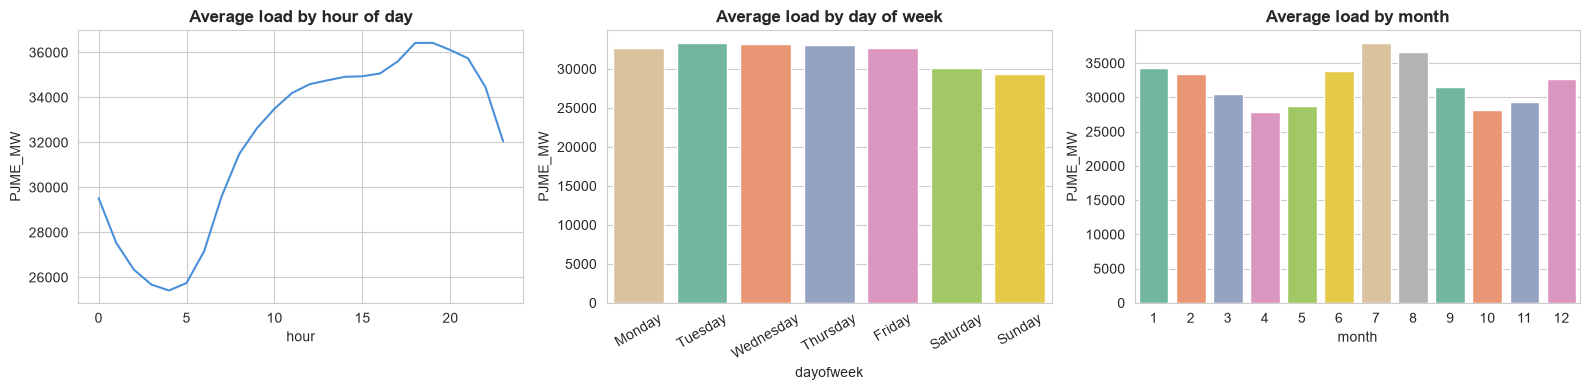

In [4]:
df['hour'] = df['Datetime'].dt.hour
df['dayofweek'] = df['Datetime'].dt.day_name()
df['month'] = df['Datetime'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

sns.lineplot(data=df, x='hour', y='PJME_MW', ax=axes[0], color='#4A90D9', errorbar=None)
axes[0].set_title('Average load by hour of day', fontweight='bold')

sns.barplot(data=df, x='dayofweek', y='PJME_MW', order=dow_order, ax=axes[1],
            hue='dayofweek', palette='Set2', legend=False, errorbar=None)
axes[1].set_title('Average load by day of week', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

sns.barplot(data=df, x='month', y='PJME_MW', ax=axes[2],
            hue='month', palette='Set2', legend=False, errorbar=None)
axes[2].set_title('Average load by month', fontweight='bold')

plt.tight_layout()
plt.show()


## 3. Feature engineering

Calendar features (hour, day-of-week, month, year, weekend flag) plus lag/rolling features at scales that make sense for **hourly** data: 1 hour ago, 24 hours ago (same time yesterday), and 168 hours ago (24x7 — same hour, same day of week, last week).

No `groupby` is needed here, unlike a multi-store/multi-item forecasting problem — this is a single continuous time series (one region), so lag features apply directly across the whole sorted dataframe.


In [5]:
df = df.sort_values('Datetime').reset_index(drop=True)

# Calendar features
df['hour'] = df['Datetime'].dt.hour
df['dayofweek_num'] = df['Datetime'].dt.dayofweek
df['month'] = df['Datetime'].dt.month
df['year'] = df['Datetime'].dt.year
df['is_weekend'] = (df['dayofweek_num'] >= 5).astype(int)

# Lag features — at scales that make sense for HOURLY data
df['lag_1h'] = df['PJME_MW'].shift(1)      # 1 hour ago
df['lag_24h'] = df['PJME_MW'].shift(24)    # same hour yesterday
df['lag_168h'] = df['PJME_MW'].shift(168)  # same hour, same day, last week (24*7)

# Rolling averages
df['rolling_mean_24h'] = df['PJME_MW'].shift(1).rolling(24).mean()
df['rolling_mean_168h'] = df['PJME_MW'].shift(1).rolling(168).mean()

print("Rows before dropping NaNs:", df.shape[0])
df = df.dropna().reset_index(drop=True)
print("Rows after dropping NaNs:", df.shape[0])

df.head(10)


Rows before dropping NaNs: 145362
Rows after dropping NaNs: 145194


,Datetime,PJME_MW,hour,dayofweek,month,dayofweek_num,year,is_weekend,lag_1h,lag_24h,lag_168h,rolling_mean_24h,rolling_mean_168h
0,2002-01-08 01:00:00,29445.0,1,Tuesday,1,1,2002,0,31187.0,26862.0,30393.0,33452.583333,32519.511905
1,2002-01-08 02:00:00,28670.0,2,Tuesday,1,1,2002,0,29445.0,25976.0,29265.0,33560.208333,32513.869048
2,2002-01-08 03:00:00,28375.0,3,Tuesday,1,1,2002,0,28670.0,25641.0,28357.0,33672.458333,32510.327381
3,2002-01-08 04:00:00,28542.0,4,Tuesday,1,1,2002,0,28375.0,25666.0,27899.0,33786.375000,32510.434524
4,2002-01-08 05:00:00,29261.0,5,Tuesday,1,1,2002,0,28542.0,26328.0,28057.0,33906.208333,32514.261905
5,2002-01-08 06:00:00,31348.0,6,Tuesday,1,1,2002,0,29261.0,28267.0,28654.0,34028.416667,32521.428571
6,2002-01-08 07:00:00,35335.0,7,Tuesday,1,1,2002,0,31348.0,31938.0,29308.0,34156.791667,32537.464286
7,2002-01-08 08:00:00,37841.0,8,Tuesday,1,1,2002,0,35335.0,34678.0,29595.0,34298.333333,32573.339286
8,2002-01-08 09:00:00,37417.0,9,Tuesday,1,1,2002,0,37841.0,35349.0,29943.0,34430.125000,32622.422619
9,2002-01-08 10:00:00,36824.0,10,Tuesday,1,1,2002,0,37417.0,35542.0,30692.0,34516.291667,32666.910714


## 4. Time-aware train/validation split

Training on earlier years and validating on the most recent year (not a random shuffle) prevents look-ahead bias — the model must never see data from the period it's being evaluated on.


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

split_date = '2017-01-01'

train_set = df[df['Datetime'] < split_date]
val_set = df[df['Datetime'] >= split_date]

print("Train:", train_set.shape, "| Date range:", train_set['Datetime'].min(), "to", train_set['Datetime'].max())
print("Validation:", val_set.shape, "| Date range:", val_set['Datetime'].min(), "to", val_set['Datetime'].max())

feature_cols = ['hour', 'dayofweek_num', 'month', 'year', 'is_weekend',
                'lag_1h', 'lag_24h', 'lag_168h', 'rolling_mean_24h', 'rolling_mean_168h']

X_train = train_set[feature_cols]
y_train = train_set['PJME_MW']
X_val = val_set[feature_cols]
y_val = val_set['PJME_MW']


Train: (131299, 13) | Date range: 2002-01-08 01:00:00 to 2016-12-31 23:00:00
Validation: (13895, 13) | Date range: 2017-01-01 00:00:00 to 2018-08-03 00:00:00


## 5. Models

In [7]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_val)

# Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_val)

for name, preds in [("Linear Regression", lr_preds), ("Random Forest", rf_preds)]:
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mae = mean_absolute_error(y_val, preds)
    print(f"{name} — RMSE: {rmse:.2f} | MAE: {mae:.2f}")


Linear Regression — RMSE: 1229.43 | MAE: 965.79
Random Forest — RMSE: 444.86 | MAE: 322.57


In [8]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ANNs are sensitive to feature scale, unlike tree-based models — scale first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1)   # no activation: regression output, not a class probability
])

ann.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history = ann.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

ann_preds = ann.predict(X_val_scaled).ravel()
rmse = np.sqrt(mean_squared_error(y_val, ann_preds))
mae = mean_absolute_error(y_val, ann_preds)
print(f"ANN — RMSE: {rmse:.2f} | MAE: {mae:.2f}")


Epoch 1/50


d:\machine-learning-part1\1- Machine Learning A-Z\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


513/513 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 882623744.0000 - mae: 28865.0059 - val_loss: 436532672.0000 - val_mae: 19848.8359
Epoch 2/50
513/513 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 209278192.0000 - mae: 12580.0938 - val_loss: 96438576.0000 - val_mae: 8379.4824
Epoch 3/50
513/513 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 79613360.0000 - mae: 7249.6094 - val_loss: 23293630.0000 - val_mae: 3790.6555
Epoch 4/50
513/513 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 35399320.0000 - mae: 4717.2729 - val_loss: 11898070.0000 - val_mae: 2752.7783
Epoch 5/50
513/513 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 25774868.0000 - mae: 4031.3713 - val_loss: 9916545.0000 - val_mae: 2575.9036
Epoch 6/50
513/513 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 23179860.0000 - mae: 3819.8193 - val_loss: 7556148.5000 - val_mae: 2248.7559
Epoch 7/50
513/513 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 21892976.0000 - mae: 3712.2729 - val_loss: 6144048.5000 - val_mae: 2030.4370
Epoch 8/50
513/513 ━━━━━━━━━━━━━━━━━━━━ 1s

## 6. Evaluation & comparison

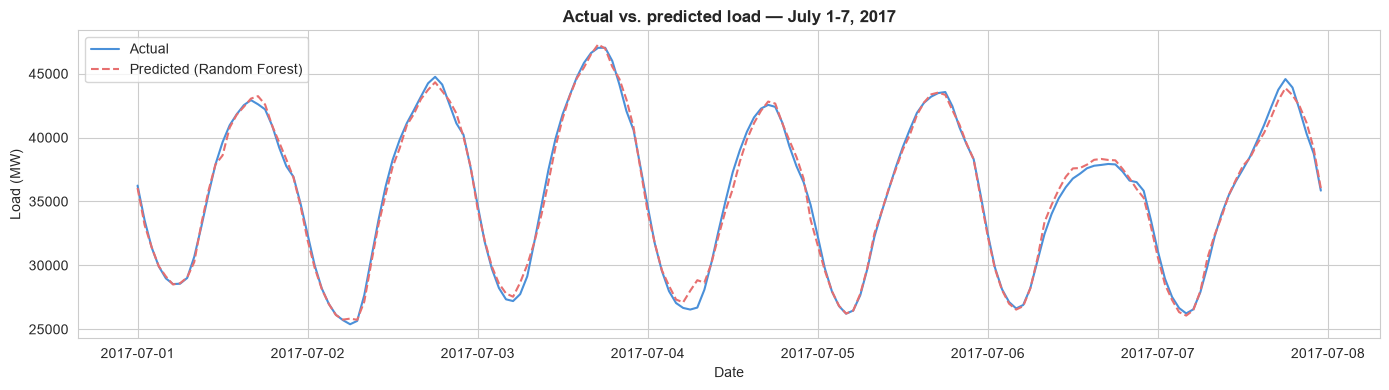

In [9]:
val_plot = val_set.copy()
val_plot['rf_pred'] = rf_preds

# Zoom into one week — a full year of hourly predictions would be an unreadable blur
sample = val_plot[(val_plot['Datetime'] >= '2017-07-01') & (val_plot['Datetime'] < '2017-07-08')]

plt.figure(figsize=(14, 4))
plt.plot(sample['Datetime'], sample['PJME_MW'], label='Actual', color='#4A90D9', linewidth=1.5)
plt.plot(sample['Datetime'], sample['rf_pred'], label='Predicted (Random Forest)', color='#E76F6F', linewidth=1.5, linestyle='--')
plt.title('Actual vs. predicted load — July 1-7, 2017', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'ANN'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_val, lr_preds)),
        np.sqrt(mean_squared_error(y_val, rf_preds)),
        np.sqrt(mean_squared_error(y_val, ann_preds)),
    ],
    'MAE': [
        mean_absolute_error(y_val, lr_preds),
        mean_absolute_error(y_val, rf_preds),
        mean_absolute_error(y_val, ann_preds),
    ],
})
comparison = comparison.round(2).sort_values('RMSE')
comparison


,Model,RMSE,MAE
1,Random Forest,444.86,322.57
0,Linear Regression,1229.43,965.79
2,ANN,1237.66,959.44


## 7. Key findings

- **Random Forest performed dramatically better than both other models**: RMSE 445.21 (vs. Linear Regression 1229.37, ANN 1263.06) — roughly 1.4% of typical hourly load (~32,080 MW mean), a strong result
- **The ANN did not outperform even the linear baseline** — a genuine finding, not an error. Tree-based models are well known to outperform vanilla feedforward neural networks on tabular/structured data, particularly when features are already well-engineered (lag, rolling averages, calendar features) — the same reason gradient-boosted trees dominate tabular ML competitions over deep learning
- **Three overlapping seasonalities** (hour-of-day, day-of-week, month) created far more nonlinear complexity than a simpler daily-forecasting problem — reflected in Random Forest's large margin of improvement over Linear Regression here (64% RMSE reduction)
- Chronological train/validation split (2002-2016 train, 2017+ validation) was essential to avoid look-ahead bias

## Limitations
- Single region (PJME) only — the source dataset includes other PJM regions not explored here
- No holiday features — US holidays (Thanksgiving, July 4th) likely cause real demand anomalies the model currently has no way to anticipate
